In [4]:
import os
import json 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib

RAWPATH ='./outputs/2024-10-08/'
# RAWPATH ='./outputs/'
# Put the "v2.jsonl" file in datasets directory 
DATADIR = '/Users/bangbui/workspace/TSandLanguage/data/processed/'

def plot_preds(time_series, pred_series , methods_name , uuid  , test ):
    plt.figure(figsize=(10, 6))
    plt.plot(time_series , label='Ori. Time Series',linewidth =2 , color = 'black')
    
    for loc in range(len(pred_series)):
        print(f"loc : {loc}")
        p = pred_series[loc]
        print(f"len of p : {len(p)}")
        method_name = methods_name[loc]
        mae = round(np.mean(np.abs(p-test)) , 2) 
        plt.plot(range(len(time_series) - len(p), len(time_series)), p, label=method_name+'--mae:{}'.format(mae), linestyle='--' ,linewidth =3)
        
    test_length =  len(pred_series[0])
    train_length = len(time_series) - test_length
    
    meanP = np.array([np.mean(time_series[:train_length])] * test_length)
    plt.plot(range(train_length, len(time_series)) ,meanP, label='MP', linestyle='--')
    
    plt.xlabel('uuid : {}'.format(uuid))
    plt.ylabel('Value')
    plt.title('Time Series and forecasting results')
    plt.legend()
    plt.show()
    
def get_common_uuids():
    out_path = RAWPATH
    # ojc_0 = 'gpt-4-llm_wo_context'               
    # ojc_1 = 'gpt-4-llmtime_wo_context'               
    # ojc_2 = 'gpt-4-llmtime_wi_Ca'                 
    # ojc_3 = 'gpt-4-llmtime_wi_Ch'                
    # ojc_4 = 'gpt-4-llmtime_wi_ChMe'           
    # ojc_5 = 'gpt-4-llmtime_wi_CaMe'
    ojc_6 = 'gpt-4-llmtime_wi_all'     
    # ojc_7 = 'gpt-4-llm_wi_all'
    
    imprs_name = [  
        # 'llm_wo_context' , 
        # 'llmtime_wo_context' , 
        # 'llmtime_wi_Ca' , 
        # 'llmtime_wi_Ch' , 
        # 'llmtime_wi_ChMe' ,
        # 'llmtime_wi_CaMe' ,
        'llmtime_wi_all' , 
        # 'llm_wi_all',
    ]
    ojcs = [
        # ojc_0 , 
        # ojc_1, 
        # ojc_2, 
        # ojc_3, 
        # ojc_4, 
        # ojc_5, 
        ojc_6 
        # ojc_7
    ]
    
    output_dirs = []
    for ojc  in ojcs:
        output_dirs.append('{}{}'.format(out_path, ojc))
        print("out_entity : "+ojc , os.listdir('{}{}'.format(out_path, ojc)) )
    # Keep common UUID
    common_elements = set( os.listdir(output_dirs[0]))
    for i in range(0,len(output_dirs)):
        common_elements = common_elements.intersection(set(os.listdir(output_dirs[i])))
    output_uuids = list(common_elements)
    print('# of UUID:' , len(output_uuids) )

    return output_dirs , output_uuids , imprs_name

def get_datasets(testfrac=0.2 ,  datasize = 10 ):
    data_list = pd.read_json(os.path.join(DATADIR, 'TS_Dataset.jsonl'), lines=True)
    print(f"len of data_list : {len(data_list)}")
    datas = []
    data_indexs =[]
    for index, row in data_list.iterrows():
        print(f"datsets index : {index}")
        series = pd.Series(row['series'])
        splitpoint = int(len(series)*(1-testfrac))
        train = series.iloc[:splitpoint]
        test  = series.iloc[splitpoint:]
        datas.append((train, test , ''))
        data_indexs.append(row['uuid'])
        
        if index > datasize : break
    datasets = dict(zip(data_indexs,datas))
    return datasets
    
def draw_predict_curves(number_of_plots=10):
    output_dirs , output_uuids , methods_name = get_common_uuids()
    # datasets =  get_datasets()
    datasets =  get_datasets(0.2,8787)
    assert len(output_dirs) == len(methods_name)
    model= 'gpt-4'
    count_plts =1
    for ds_name in datasets.keys() : 
        print(f"ds_name : {ds_name}")
        uuid = str(ds_name.split(".")[0])
        if uuid+'.pkl' not in output_uuids : 
            continue 
        preds =[]
        for idx in range(len(output_dirs)):
            print(f"idx : ", idx) 
            output_dir = output_dirs[idx]
            
            with open(f'{output_dir}/{uuid}.pkl', 'rb') as f:
                out = pickle.load(f)
                
            train , test , _ = datasets[uuid]
            print(f"len of train : {len(train)}")
            print(f"len of test : {len(test)}")
            time_series = np.append(train.values , test.values , 0)
            print(f"len of time_series : {len(time_series)}")
            pred = out[model]['median'].values
            print(f"len of pred : {len(pred)}")
            assert len(pred) == len(test)
            preds.append(pred)
            
        plot_preds(time_series, preds , methods_name ,uuid , test )
        count_plts +=1
        print(f"max number of plots : {count_plts}") 
        if count_plts > number_of_plots :
            break 

out_entity : gpt-4-llmtime_wi_all ['f1e0cf26-8707-4e47-a64e-0a51c1867cc6.pkl']
# of UUID: 1
len of data_list : 8787
datsets index : 0
datsets index : 1
datsets index : 2
datsets index : 3
datsets index : 4
datsets index : 5
datsets index : 6
datsets index : 7
datsets index : 8
datsets index : 9
datsets index : 10
datsets index : 11
datsets index : 12
datsets index : 13
datsets index : 14
datsets index : 15
datsets index : 16
datsets index : 17
datsets index : 18
datsets index : 19
datsets index : 20
datsets index : 21
datsets index : 22
datsets index : 23
datsets index : 24
datsets index : 25
datsets index : 26
datsets index : 27
datsets index : 28
datsets index : 29
datsets index : 30
datsets index : 31
datsets index : 32
datsets index : 33
datsets index : 34
datsets index : 35
datsets index : 36
datsets index : 37
datsets index : 38
datsets index : 39
datsets index : 40
datsets index : 41
datsets index : 42
datsets index : 43
datsets index : 44
datsets index : 45
datsets index : 46
d

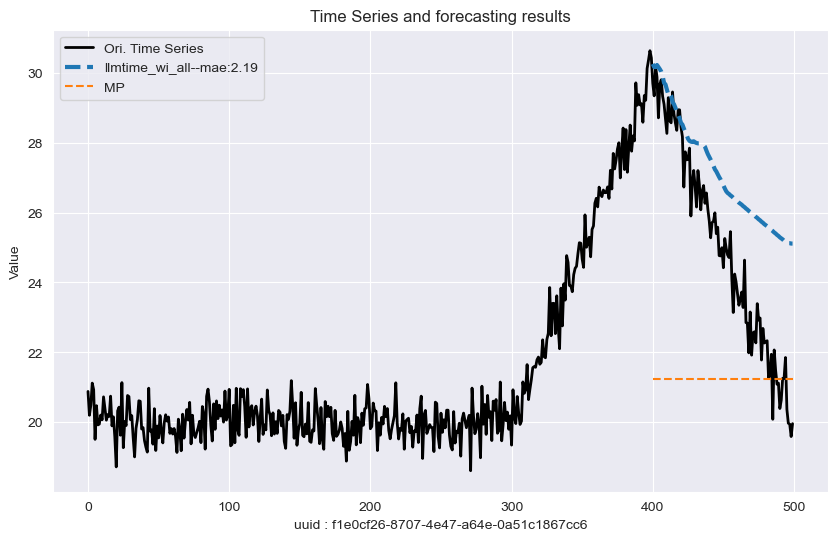

max number of plots : 2
ds_name : b7169a0a-16ef-40bf-bda3-f5c45943c19e
ds_name : 8e73560d-f7cd-4a08-bb08-f03ef6685ba2
ds_name : e56dbb22-c131-49e4-bfe5-8ad29ef1561e
ds_name : 1497b42f-d9b6-4112-bdc7-8ece62d8c977
ds_name : 4e99238c-5a19-47c1-af16-a4379c7ef607
ds_name : c9a96c1d-fd55-41b5-94b0-33d4a0d63288
ds_name : 8d269711-8ba7-4837-a494-89e23592f53e
ds_name : 82afc5a6-7ccb-4fd5-b6d9-0b4bdee2ab43
ds_name : e830d5f7-2a10-4b05-aba6-de959fd109ee
ds_name : 62506e2c-4995-4a72-9753-a22d2110738b
ds_name : fe0b2fd5-151f-4991-8558-59ead54f7af5
ds_name : 446575de-9312-457a-9054-99ae0f36c466
ds_name : 2571f7db-ee38-443a-b914-6139bcee0466
ds_name : 1db8e283-b40b-4a90-b43b-b020bd0c199b
ds_name : 7fa208b5-fc21-4de5-8380-a6382826c24a
ds_name : e8ce4bfd-474b-4671-9e47-5ac3291dc473
ds_name : 62b09362-f11a-4bb2-8053-4a08252bc9c4
ds_name : 29701769-08ae-4fc9-afd6-2dced3b294e3
ds_name : ac1185f7-88a5-440c-a5a6-dc7188ccfeba
ds_name : 5b2178c0-1c86-449e-9694-60cd60ba2e54
ds_name : 1e0b0b68-e0fa-49ad-ba65-b2

In [5]:
draw_predict_curves(number_of_plots=1000)